In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata.utils import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
from astropy.table import Table
from astropy.nddata import extract_array
from astropy.wcs.utils import skycoord_to_pixel
from reproject import reproject_interp
from astropy.visualization import make_lupton_rgb
import astropy.units as u
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.wcs.utils import fit_wcs_from_points
from matplotlib.colors import LinearSegmentedColormap

In [2]:
import argparse
import datetime
import glob
import json
import os
import pdb
import requests
import shutil
import sys
import traceback

from astrocut import fits_cut, img_cut
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.table import Table
from astropy.table import unique
import astropy.wcs as wcs
from astropy.wcs import WCS
from astroquery.mast import Observations

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image, ImageDraw, ImageFont, ImageEnhance
from PIL.PngImagePlugin import PngInfo
from reproject import reproject_interp  # https://reproject.readthedocs.io/en/stable/
from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs
from scipy.optimize import golden

from copy import deepcopy
from os.path import join
from os.path import expanduser
home = expanduser("~")

import astropy  # version 4.2 is required to write magnitudes to ecsv file
import astropy.io.fits as pyfits
from astropy.table import QTable
import astropy.units as u
from astropy.visualization import make_lupton_rgb, SqrtStretch, LogStretch, LinearStretch, hist
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.stats import sigma_clipped_stats
import photutils
from importlib import reload




In [3]:
# Trilogy Code
def da(k):
    a1 = k * (x1 - x0) + 1
    a2 = k * (x2 - x0) + 1
    a1n = a1 ** n
    a1n = np.abs(a1n)  # Don't want the solutions where a1 & a2 are both negative!
    da1 = a1n - a2
    k = np.abs(k)
    if k == 0:
        return da(1e-10)
    else:
        da1 = da1 / k  # To avoid solution k = 0!
    return abs(da1)


def imscale2(data, levels, y1):
    # x0, x1, x2  YIELD  0, y1, 1,  RESPECTIVELY
    # y1 = noiselum
    global n, x0, x1, x2  # So that golden can use them
    x0, x1, x2 = levels
    if y1 == 0.5:
        k = (x2 - 2 * x1 + x0) / float(x1 - x0) ** 2
    else:
        n = 1 / y1
        k = np.abs(golden(da))
    r1 = np.log10(k * (x2 - x0) + 1)
    v = np.ravel(data)
    v = clip2(v, 0, None)
    d = k * (v - x0) + 1
    d = clip2(d, 1e-30, None)
    z = np.log10(d) / r1
    z = np.clip(z, 0, 1)
    z.shape = data.shape
    z = z * 255
    z = z.astype(np.uint8)
    return z


def clip2(m, m_min=None, m_max=None):
    # nanmin and nanmax important to ignore nan values
    # otherwise you'll get all 0's
    if m_min == None:
        m_min = np.nanmin(m)
    if m_max == None:
        m_max = np.nanmax(m)
    return np.clip(m, m_min, m_max)


# PREVIOUSLY in colorimage.py
def set_levels(data, pp, stripneg=False, sortedalready=False):
    if sortedalready:
        vs = data
    else:
        print('sorting...')
        vs = np.sort(data.flat)
    if stripneg:  # Get rid of negative values altogether!
        # This is the way I was doing it for a while
        # Now that I'm not, resulting images should change (get lighter)
        i = np.searchsorted(vs, 0)
        vs = vs[i + 1:]
    else:  # Clip negative values to zero
        vs = clip2(vs, 0, None)
    ii = np.array(pp) * len(vs)
    ii = ii.astype(int)
    ii = np.clip(ii, 0, len(vs) - 1)
    levels = vs.take(ii)
    # print ii, levels, vs, sort(vs)
    return levels


def determine_scaling(data, unsatpercent, noisesig=1, correctbias=True, noisefloorsig=2):
    """Determines data values (x0,x1,x2) which will be scaled to (0,noiselum,1)"""
    # Robust mean & standard deviation
    datasorted = data + 0
    datasorted[np.isnan(datasorted)] = 0  # set all nan values to zero
    datasorted = np.sort(datasorted.flat)
    if datasorted[0] == datasorted[-1]:  # data is all one value
        levels = 0, 1, 100  # whatever
    else:
        data_mean, data_median, data_stddev = sigma_clipped_stats(datasorted, mask_value=0)
        m = data_mean
        r = data_stddev
        print('%g +/- %g' % (m, r))

        if correctbias:
            x0 = m - noisefloorsig * r
        else:
            x0 = 0
        x1 = m + noisesig * r
        x2 = set_levels(datasorted, np.array([unsatpercent]), sortedalready=True)[0]
        levels = x0, x1, x2
    return levels


def stamp_extent(data, sample_size=1000, dx=0, dy=0, xc=0, yc=0):
    data_shape = data.shape
    if len(data_shape) == 2:
        ny, nx = data.shape
    else:
        ny, nx, three = data.shape

    if yc:
        dy = 0
    else:
        yc = int(ny / 2)

    if xc:
        dx = 0
    else:
        xc = int(nx / 2)

    ylo = yc - sample_size / 2 + dy
    yhi = yc + sample_size / 2 + dy

    xlo = xc - sample_size / 2 + dx
    xhi = xc + sample_size / 2 + dx

    ylo = int(np.clip(ylo, 0, ny))
    yhi = int(np.clip(yhi, 0, ny))
    xlo = int(np.clip(xlo, 0, nx))
    xhi = int(np.clip(xhi, 0, nx))
    # print(xlo, xhi, ylo, yhi)
    return xlo, xhi, ylo, yhi


# def image_stamps(data, sample_size=1000, dx=0, dy=0, xc=0, yc=0):
# xlo, xhi, ylo, yhi = stamp_extent(data, sample_size, dx, dy)

def image_stamps(data, extent):
    xlo, xhi, ylo, yhi = extent
    stamps = data[ylo:yhi, xlo:xhi]
    return stamps


image_stamp = image_stamps


def roundint(x):
    return int(np.round(x))


def slices_extent(x, y, dx, dy=0):
    dy = dy or dx
    xlo = roundint(x - dx)
    xhi = roundint(x + dx + 1)
    ylo = roundint(y - dy)
    yhi = roundint(y + dy + 1)
    xslice = slice(xlo, xhi)
    yslice = slice(ylo, yhi)
    slices = yslice, xslice
    extent = xlo, xhi, ylo, yhi
    return slices, extent

In [4]:
def determine_pixel_scale(image_file):
    """Access image and return the image WCS information and platescale (arcsec/pixel). Borrowed and adapted
    from https://github.com/spacetelescope/sn_dust/blob/main/colored_images/color_image_generic.ipynb

    Parameters
    ----------
    image_file : str
        image name (with full path)

    Returns
    -------
    imwcs : Astropy.wcs.wcs.WCS object
        The world coordinate system (WCS) information extracted from the input image's header
    image_pixel_scale : float
        The image's pixel scale in arcseconds/pixel
    """
    hdu = fits.open(image_file)
    imwcs = wcs.WCS(hdu[0].header, hdu)
    image_pixel_scale = wcs.utils.proj_plane_pixel_scales(imwcs)[0]
    image_pixel_scale *= imwcs.wcs.cunit[0].to('arcsec')

    return imwcs, image_pixel_scale


In [5]:
def orient_north_hst(hst_file, output_fits_path):
    # Load FITS
    hdul = fits.open(hst_file)
    image_data = hdul[1].data
    wcs = WCS(hdul[1].header)

    # Extract celestial WCS only (ignore spectral if present)
    wcs = wcs.celestial

    # Make a North-up TAN projection grid with same pixel scale & size
    # This uses astropy.wcs.utils to generate a "target WCS"
    ny, nx = image_data.shape
    pixel_scales = proj_plane_pixel_scales(wcs)  # deg/pixel
    scale = np.mean(pixel_scales) * 3600  # arcsec/pix

    # Center of the image in sky coords
    center = wcs.pixel_to_world(nx/2, ny/2)

    # Create target WCS (north-up, same center, TAN)
    target_header = fits.Header()
    target_header['NAXIS'] = 2
    target_header['NAXIS1'] = nx
    target_header['NAXIS2'] = ny
    target_header['CTYPE1'] = 'RA---TAN'
    target_header['CTYPE2'] = 'DEC--TAN'
    target_header['CUNIT1'] = 'deg'
    target_header['CUNIT2'] = 'deg'
    target_header['CRPIX1'] = nx/2
    target_header['CRPIX2'] = ny/2
    target_header['CRVAL1'] = center.ra.deg
    target_header['CRVAL2'] = center.dec.deg
    target_header['CD1_1'] = -pixel_scales[0]  # deg/pix
    target_header['CD1_2'] = 0
    target_header['CD2_1'] = 0
    target_header['CD2_2'] = pixel_scales[1]

    wcs_north = WCS(target_header)

    # Reproject
    array_out, footprint = reproject_interp((image_data, wcs), wcs_north, shape_out=(ny, nx))

    fits.writeto(output_fits_path, array_out, wcs_north.to_header(), overwrite=True)

    return array_out


In [6]:
hst555 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/HST/drz_lvl3/F555W_drz.fits'
hst657 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/HST/drz_lvl3/F657N_drz.fits'


hst555N = orient_north_hst(hst555, '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/HST/drz_lvl3/north_oriented/F555N_drz_N.fits')
hst657N = orient_north_hst(hst657, '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/HST/drz_lvl3/north_oriented/F657N_drz_N.fits')

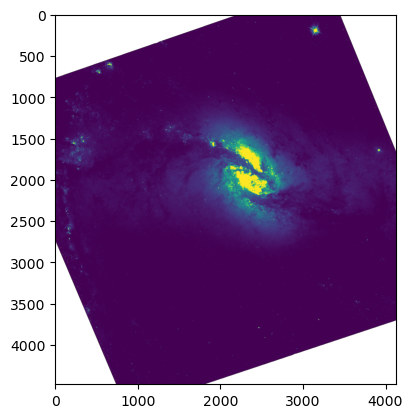

In [7]:
plt.imshow(np.flipud(hst555N),vmin=0.01,vmax=1)

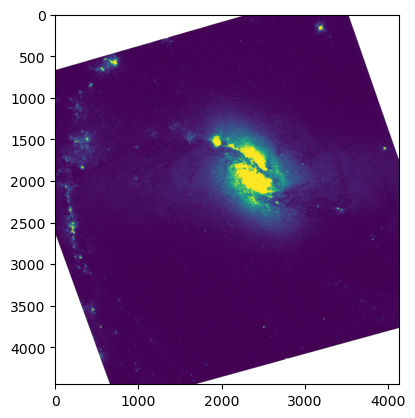

In [8]:
plt.imshow(np.flipud(hst657N),vmin=0.01,vmax=0.1)

In [9]:
hst555N = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/HST/drz_lvl3/north_oriented/F555W_drz_N.fits'
hst657N = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/HST/drz_lvl3/north_oriented/F657N_drz_N.fits'

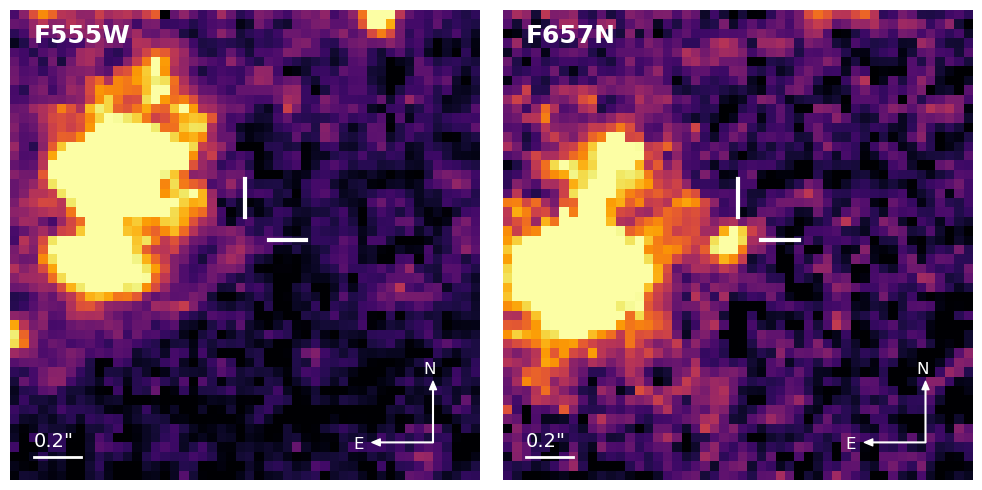

In [10]:
def plot_two_fits_side_by_side(file1, file2, ra, dec, size=100, cmap="magma",
                               stretch="linear", vmin=None, vmax=None, percent=99.5):
    """
    Plot two FITS images side by side, centered on (RA, Dec), with crosshairs.
    Includes scaling options.

    Parameters
    ----------
    file1, file2 : str
        Paths to the FITS files.
    ra, dec : float
        Target RA and Dec in degrees.
    size : int
        Cutout size in pixels (n x n).
    cmap : str
        Colormap.
    stretch : str
        "linear", "log", or "percentile".
    vmin, vmax : float
        Explicit brightness limits. If None, auto-scaling is used.
    percent : float
        For percentile scaling (e.g. 99.5 = clip top 0.5% of pixels).
    """

    hdu1 = fits.open(file1)[0]
    hdu2 = fits.open(file2)[0]

    wcs1 = WCS(hdu1.header)
    wcs2 = WCS(hdu2.header)

    position = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)

    cutout1 = Cutout2D(hdu1.data, position, (size, size), wcs=wcs1)
    cutout2 = Cutout2D(hdu2.data, position, (size, size), wcs=wcs2)

    cutouts = [cutout1, cutout2]

    # Brightness scaling
    def get_limits(data):
        if vmin is not None and vmax is not None:
            return vmin, vmax
        if stretch == "percentile":
            vmin_p, vmax_p = np.nanpercentile(data, [(100-percent), percent])
            return vmin_p, vmax_p
        if stretch == "log":
            return np.nanmin(data[data > 0]), np.nanmax(data)
        return np.nanmin(data), np.nanmax(data)  # linear default

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={'projection': cutout1.wcs})

    for ax, cutout, title in zip(axes, cutouts, ['F555W', 'F657N']):
        vmin_, vmax_ = get_limits(cutout.data)
        if stretch == "log":
            im = ax.imshow(np.log10(cutout.data), origin="lower", cmap=cmap,
                           vmin=np.log10(vmin_), vmax=np.log10(vmax_))
        else:
            im = ax.imshow(cutout.data, origin="lower", cmap=cmap,
                           vmin=vmin_, vmax=vmax_)
        # ax.set_title(title)
        ax.set_xlabel("RA")
        ax.set_ylabel("Dec")

    # NE Arrows
    axes[0].text(43.5, 10.8, 'N', fontsize=12, color = 'white')
    axes[0].text(36, 2.8, 'E', fontsize=12, color = 'white')

    axes[0].annotate('', xy=(0.9, 0.21), xytext=(0.9, 0.08),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(color='white', width=0.5, headwidth=5, headlength=6),
            horizontalalignment='center', verticalalignment='bottom',
            fontsize=16,color='white')
    axes[0].annotate('', xy=(0.77, 0.08), xytext=(0.9, 0.08),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(color='white', width=0.5, headwidth=5, headlength=6),
            horizontalalignment='center', verticalalignment='bottom',
            fontsize=16,color='white')
    
    axes[1].text(43.5, 10.8, 'N', fontsize=12, color = 'white')
    axes[1].text(36, 2.8, 'E', fontsize=12, color = 'white')

    axes[1].annotate('', xy=(0.9, 0.21), xytext=(0.9, 0.08),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(color='white', width=0.5, headwidth=5, headlength=6),
            horizontalalignment='center', verticalalignment='bottom',
            fontsize=16,color='white')
    axes[1].annotate('', xy=(0.77, 0.08), xytext=(0.9, 0.08),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(color='white', width=0.5, headwidth=5, headlength=6),
            horizontalalignment='center', verticalalignment='bottom',
            fontsize=16,color='white')
    
    # Scale bar
    # HST Scale Bar
    # 0.2" = 5 pixels
    x0 = 2
    y0 = 2
    sc_x = [x0, x0+5] 
    sc_y = [y0, y0]
    axes[0].plot(sc_x, sc_y, color='white', linewidth=2, linestyle='-')
    axes[0].text(2, 3, '0.2"', fontsize=14, color = 'white')
    axes[1].plot(sc_x, sc_y, color='white', linewidth=2, linestyle='-')
    axes[1].text(2, 3, '0.2"', fontsize=14, color = 'white')


    # crosshairs
    window = size // 2
    # horizontal line
    axes[1].plot([window+2,window+6], [window,window], color='white', linewidth=3, linestyle='-')
    # vertical line
    axes[1].plot([window-0.5,window-0.5], [window+2.5,window+6.5], color='white', linewidth=3, linestyle='-')

    axes[0].plot([window+2,window+6], [window,window], color='white', linewidth=3, linestyle='-')
    # vertical line
    axes[0].plot([window-0.5,window-0.5], [window+2.5,window+6.5], color='white', linewidth=3, linestyle='-')

    # turn off axis for clean plotting
    axes[0].axis("off")
    axes[1].axis("off")

    # Add filter and sn text
    axes[0].text(2, 46, 'F555W', fontsize=18, color = 'white', fontweight = 'bold')
    axes[1].text(2, 46, 'F657N', fontsize=18, color = 'white', fontweight = 'bold')

    # axes[1].text(33.5, 43, 'SN 1983V', fontsize=18, color = 'white', fontweight = 'bold')


    # plt.tight_layout()
    # plt.show()

plot_two_fits_side_by_side(hst555N, hst657N, ra=53.3817329, dec=-36.1486728, size=50, stretch='percentile', percent=93, cmap='inferno')

plt.tight_layout()
plt.savefig('/Users/sophiakressy/Desktop/HST_images.pdf')

In [11]:
def make_cutout_image(image_files_dict, target_name, target_ra, target_dec, ref_img_name, instrument_name):
    """Create cutout image and write them to .jpg file

    Parameters
    ----------
    image_files_dict : dict
        dict of image names (with full paths) to process
    target_name : str
        target name
    target_ra : float
        target right ascension, in degrees
    target_dec : float
        target declination, in degrees
    ref_img_name : str
        Name of the reference image.
    instrument_name : str
        JWST instrument name.

    Returns
    -------
    Nothing.
    """
    filters = sorted(image_files_dict.keys())
    print(image_files_dict.keys())
    cmap = plt.colormaps['rainbow']

    # Filter R G B
    # f0770w  0.50  0.00  1.00
    # f1000w  0.17  0.87  0.87
    # f1130w  0.83  0.87  0.50
    # f2100w  1.00  0.00  0.00
    
    filter_colors = {}
    color_info = {}
    for i, filt in enumerate(filters):
        x_min = 0.0  # bluest filter will be purple
        #x_min = 0.1  # bluest filter will be blue
        x = i / (len(filters) - 1) * (1 - x_min) + x_min
        r_lum, g_lum, b_lum, alpha = cmap(x)
        rgb_lum = np.array([r_lum, g_lum, b_lum])
        filter_colors[filt] = rgb_lum
        print(filt, ' %4.2f' % r_lum, ' %4.2f' % g_lum, ' %4.2f' % b_lum)
        # padding = " "*(6 - len(filt))
        # foo = "{}{}  {:.2f}  {:.2f}  {:.2f}".format(filt.upper(), padding, r_lum, g_lum, b_lum)
        if filt.upper().endswith("     "):
            color_info[filt.upper()] = "white"
        else:
            color_info[filt.upper()] = (r_lum, g_lum, b_lum)
    filters = filter_colors.keys()
    print(filters)

    for filt in filters:
        filter_colors[filt] = np.array(filter_colors[filt])

    rgb_lum_sum = np.zeros(3)
    for i, filt in enumerate(filters):
        rgb_lum_sum += np.array(filter_colors[filt])

    print('rgb_lum_sum', rgb_lum_sum)

    #REad in all image data
    image_data_dict_rot = {}
    for filt in filters:
        image_file = image_files_dict[filt]
        hdu = fits.open(image_file)
        data = hdu[0].data
        image_data_dict_rot[filt] = data


    # Input parameters
    # Determine size of cutout image in pixels.
    cutout_size_arcsec = 15 # size of cutout in arcseconds

    image_wcs_info, image_pixel_scale = determine_pixel_scale(ref_img_name) # get pixel scale #ref_img_name.replace("_rot.fits", ".fits")
    sample_size = int(cutout_size_arcsec/image_pixel_scale) # convert cutout size from arcsec to pixels

    dx = dy = 0  # don't use offset
    xc, yc = 412.36618, 467.07393

    noiselum = 0.20  # brightness of "the noise". adjusted up from 0.12 to 0.2 to make bracket algorithm work.
    satpercent = 0.01  # percentage of pixels allowed to saturate (e.g., to white)
    unsatpercent = 1 - 0.01 * satpercent

    noisesig = 1  # set e.g., 1-sigma noise to noiselum
    correctbias = True  ## yes because need to dip below 0 by noisefloorsig-sigma
    noisefloorsig = 1  # set black to e.g., 2-sigma below
    # previously noisesigbias

    color_saturation = 3#1.5  # increase color saturation > 1

##########


    scaled_images = {}
    levels_all = {}
    for filt in filters:
        data = image_data_dict_rot[filt]
        # data = background_subtracted_dict[filt]
        print(filt, data.shape)

        position = SkyCoord("{} {}".format(target_ra, target_dec), unit='deg')
        image_file = ref_img_name
        hdu = fits.open(image_file)
        wcs = WCS(hdu[0].header, hdu)

##############################
        if filt == 'F1130W':
            position = SkyCoord("{} {}".format(53.3817083, -36.1486180), unit='deg')
            image_file = image_files_dict[filt]
            hdu = fits.open(image_file)
            wcs = WCS(hdu[0].header, hdu)
            data = image_data_dict_rot[filt]
##############################
        # Use Cutout2d
        cutout = Cutout2D(data, position, (sample_size, sample_size), wcs=wcs, mode='partial', fill_value=0)
        stamp = cutout.data
        wcs_crop = cutout.wcs

        levels = determine_scaling(stamp.ravel(), unsatpercent, noisesig, correctbias, noisefloorsig)
        scaled = imscale2(stamp, levels, noiselum)
        levels_all[filt] = levels
        scaled_images[filt] = scaled

    rgb_total = 0
    for filt in filters:
        rgb = r, g, b = filter_colors[filt][:, np.newaxis, np.newaxis] * scaled_images[filt]
        # imrgb = np.array([r, g, b]).transpose((1,2,0)).astype(np.uint8)
        rgb_total = rgb_total + rgb

    r, g, b = rgb_average = rgb_total / rgb_lum_sum[:, np.newaxis, np.newaxis]

    imrgb = np.array([r, g, b]).transpose((1, 2, 0)).astype(np.uint8)

    im = Image.fromarray(imrgb, 'RGB')
    im = im.transpose(method=Image.Transpose.FLIP_TOP_BOTTOM)
    if color_saturation > 1:
        im = ImageEnhance.Color(im).enhance(color_saturation)

    color_image = np.asarray(im)[::-1]

    return color_image, wcs_crop, sample_size, color_info


In [12]:
# npath = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/'
# miri_north_files = [npath+'North_f770w.fits',npath+'North_f1000w.fits',npath+'North_f1130w.fits',npath+"North_f2100w.fits"]

image_files_dict = {'F0770W':'/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/North_f770w.fits',
                    'F1000W':'/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/North_f1000w.fits',
                    'F1130W':'/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/North_f1130w.fits',
                    'F2100W':'/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/North_f2100w.fits'}
target_name = 'SN1983V'
target_ra = 53.3817329 # 53.3817083
target_dec = -36.1486728 # -36.1486180
ref_img_name = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/North_f770w.fits'
instrument_name = 'MIRI'


In [13]:
color_image, wcs_crop, sample_size, color_info = make_cutout_image(image_files_dict, target_name, target_ra, target_dec, ref_img_name, instrument_name)

    # f0770w  0.50  0.00  1.00
    # f1000w  0.17  0.87  0.87
    # f1130w  0.83  0.87  0.50
    # f2100w  1.00  0.00  0.00

dict_keys(['F0770W', 'F1000W', 'F1130W', 'F2100W'])
F0770W  0.50  0.00  1.00
F1000W  0.17  0.87  0.87
F1130W  0.83  0.87  0.50
F2100W  1.00  0.00  0.00
dict_keys(['F0770W', 'F1000W', 'F1130W', 'F2100W'])
rgb_lum_sum [2.5        1.73205081 2.3660254 ]
F0770W (5554, 9610)
0.914685 +/- 0.847545
F1000W (5554, 9610)
0.264187 +/- 0.273942
F1130W (5594, 9600)
1.19956 +/- 1.10063
F2100W (5554, 9610)
0.249392 +/- 0.29986


Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


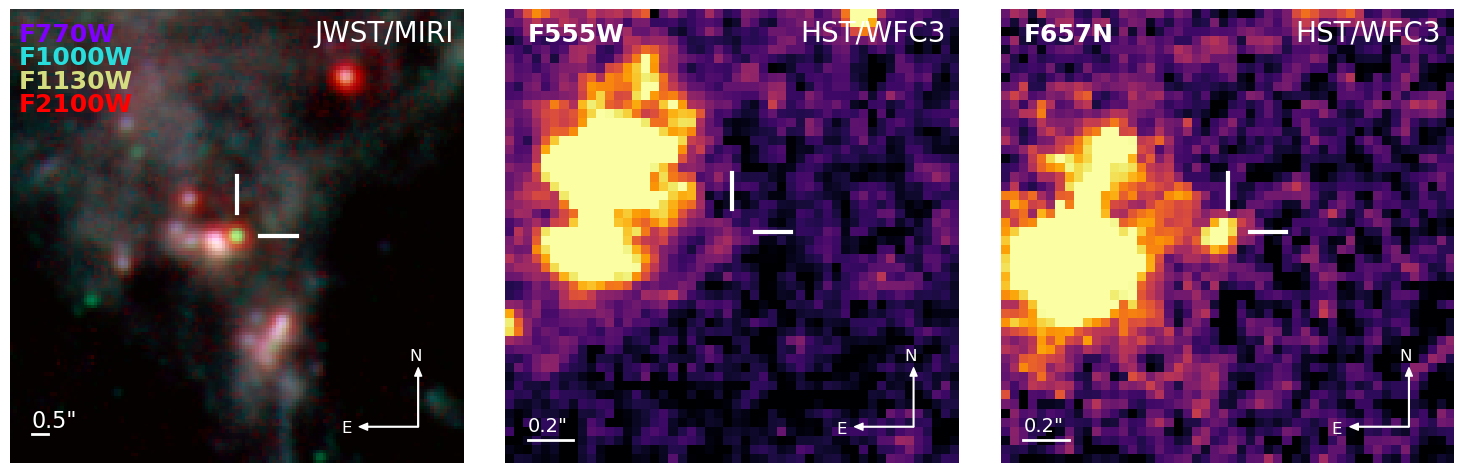

In [37]:
# COMBINE ALL!!!
cmap = 'inferno'

hdu1 = fits.open(hst555N)[0]
hdu2 = fits.open(hst657N)[0]

wcs1 = WCS(hdu1.header)
wcs2 = WCS(hdu2.header)

position = SkyCoord(ra=53.3817329*u.deg, dec=-36.1486728*u.deg)

size = 50

cutout1 = Cutout2D(hdu1.data, position, (size, size), wcs=wcs1)
cutout2 = Cutout2D(hdu2.data, position, (size, size), wcs=wcs2)

cutouts = [cutout1, cutout2]

percent = 93

vmin_p1, vmax_p1 = np.nanpercentile(cutout1.data, [(100-percent), percent])
vmin_p2, vmax_p2 = np.nanpercentile(cutout2.data, [(100-percent), percent])

fig = plt.figure(figsize=(15, 5))

# First panel: different WCS
ax1 = fig.add_subplot(1, 3, 1, projection=wcs_crop)  
ax1.imshow(np.fliplr(color_image), origin="lower", interpolation='none')

# Second panel: shared WCS
ax2 = fig.add_subplot(1, 3, 2, projection=cutout1.wcs)  
ax2.imshow(cutout1.data, origin="lower", cmap=cmap, vmin=vmin_p1, vmax=vmax_p1)

# Third panel: same WCS as second
ax3 = fig.add_subplot(1, 3, 3, projection=cutout1.wcs)  
ax3.imshow(cutout2.data, origin="lower", cmap=cmap, vmin=vmin_p2, vmax=vmax_p2)

# NE Arrows
ax2.text(43.5, 10.8, 'N', fontsize=12, color = 'white')
ax2.text(36, 2.8, 'E', fontsize=12, color = 'white')

ax2.annotate('', xy=(0.9, 0.21), xytext=(0.9, 0.08),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(color='white', width=0.5, headwidth=5, headlength=6),
        horizontalalignment='center', verticalalignment='bottom',
        fontsize=16,color='white')
ax2.annotate('', xy=(0.77, 0.08), xytext=(0.9, 0.08),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(color='white', width=0.5, headwidth=5, headlength=6),
        horizontalalignment='center', verticalalignment='bottom',
        fontsize=16,color='white')

ax3.text(43.5, 10.8, 'N', fontsize=12, color = 'white')
ax3.text(36, 2.8, 'E', fontsize=12, color = 'white')

ax3.annotate('', xy=(0.9, 0.21), xytext=(0.9, 0.08),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(color='white', width=0.5, headwidth=5, headlength=6),
        horizontalalignment='center', verticalalignment='bottom',
        fontsize=16,color='white')
ax3.annotate('', xy=(0.77, 0.08), xytext=(0.9, 0.08),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(color='white', width=0.5, headwidth=5, headlength=6),
        horizontalalignment='center', verticalalignment='bottom',
        fontsize=16,color='white')


ax1.text(118.5, 30, 'N', fontsize=12, color = 'white')
ax1.text(98, 8.5, 'E', fontsize=12, color = 'white')

ax1.annotate('', xy=(0.9, 0.21), xytext=(0.9, 0.08),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(color='white', width=0.5, headwidth=5, headlength=6),
        horizontalalignment='center', verticalalignment='bottom',
        fontsize=16,color='white')
ax1.annotate('', xy=(0.77, 0.08), xytext=(0.9, 0.08),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(color='white', width=0.5, headwidth=5, headlength=6),
        horizontalalignment='center', verticalalignment='bottom',
        fontsize=16,color='white')

# Scale bar
# HST Scale Bar
# 0.2" = 5 pixels
x0 = 2
y0 = 2
sc_x = [x0, x0+5] 
sc_y = [y0, y0]
ax2.plot(sc_x, sc_y, color='white', linewidth=2, linestyle='-')
ax2.text(2, 3, '0.2"', fontsize=14, color = 'white')
ax3.plot(sc_x, sc_y, color='white', linewidth=2, linestyle='-')
ax3.text(2, 3, '0.2"', fontsize=14, color = 'white')

# MIRI Scale Bar
# MIRI = 0.5" = 4.8 pixels
x0 = 6
y0 = 8
sc_x = [x0, x0+4.8] 
sc_y = [y0, y0]
ax1.plot(sc_x, sc_y, color='white', linewidth=2, linestyle='-')
ax1.text(x0, y0+2, '0.5"', fontsize=16, color = 'white')


# crosshairs
window = size // 2
# horizontal line
ax3.plot([window+2,window+6], [window,window], color='white', linewidth=3, linestyle='-')
# vertical line
ax3.plot([window-0.5,window-0.5], [window+2.5,window+6.5], color='white', linewidth=3, linestyle='-')

ax2.plot([window+2,window+6], [window,window], color='white', linewidth=3, linestyle='-')
# vertical line
ax2.plot([window-0.5,window-0.5], [window+2.5,window+6.5], color='white', linewidth=3, linestyle='-')

window = sample_size //2
ax1.plot([window+7,window+18], [window,window], color='white', linewidth=3, linestyle='-')
# vertical line
ax1.plot([window,window], [window+7,window+18], color='white', linewidth=3, linestyle='-')

# turn off axis for clean plotting
ax1.axis("off")
ax2.axis("off")
ax3.axis("off")

# Add filter and sn text
ax2.text(2, 46, 'F555W', fontsize=18, color = 'white', fontweight = 'bold')
ax3.text(2, 46, 'F657N', fontsize=18, color = 'white', fontweight = 'bold')

ax1.text(2, 125, 'F770W', color=color_info['F0770W'], fontweight='bold', fontsize=18)
ax1.text(2, 118, 'F1000W', fontsize=18, color=color_info['F1000W'], fontweight = 'bold')
ax1.text(2, 111, 'F1130W', fontsize=18, color=color_info['F1130W'], fontweight = 'bold')
ax1.text(2, 104, 'F2100W', fontsize=18, color=color_info['F2100W'], fontweight = 'bold')

ax1.text(90, 125, 'JWST/MIRI', fontsize=20, color='white')
ax2.text(32, 46, 'HST/WFC3', fontsize=20, color='white')
ax3.text(32, 46, 'HST/WFC3', fontsize=20, color='white')

plt.tight_layout()
# plt
plt.savefig('/Users/sophiakressy/Desktop/HST_images.pdf')



In [15]:
# npath = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/'
# miri_north_files = [npath+'North_f770w.fits',npath+'North_f1000w.fits',npath+'North_f1130w.fits',npath+"North_f2100w.fits"]

# # Open all fits images
# miri770_hdu  = fits.open(miri_north_files[0])
# miri1000_hdu = fits.open(miri_north_files[1])
# miri1130_hdu = fits.open(miri_north_files[2])
# miri2100_hdu = fits.open(miri_north_files[3])

# miri_770_data_r    = miri770_hdu[0].data
# miri_1000_data_r   = miri1000_hdu[0].data
# miri_1130_data_r   = miri1130_hdu[0].data
# miri_2100_data_r   = miri2100_hdu[0].data

# miri_770_header = miri770_hdu[0].header

# wcs_770  = WCS(miri770_hdu[0].header)
# wcs_1000 = WCS(miri1000_hdu[0].header)
# wcs_1130 = WCS(miri1130_hdu[0].header)
# wcs_2100 = WCS(miri2100_hdu[0].header)

# # Handle Nans; set Nans to 0
# miri_770_data_r[np.isnan(miri_770_data_r)] = 0
# miri_1000_data_r[np.isnan(miri_1000_data_r)] = 0
# miri_1130_data_r[np.isnan(miri_1130_data_r)] = 0
# miri_2100_data_r[np.isnan(miri_2100_data_r)] = 0

# # How to handle negative values? Not sure. Going to set to 0
# miri_770_data_r[miri_770_data_r<0] = 0.01
# miri_1000_data_r[miri_1000_data_r<0] = 0.01
# miri_1130_data_r[miri_1130_data_r<0] = 0.01
# miri_2100_data_r[miri_2100_data_r<0] = 0.01


In [16]:
# # Convert FK4 to FK5
# wcs_fk5 = wcs_770.deepcopy()
# wcs_fk5.wcs.equinox = 2000.0
# wcs_fk5.wcs.ctype = ['RA---TAN', 'DEC--TAN']
# wcs_fk5.wcs.radesys = 'ICRS'

# print(wcs_fk5.wcs.radesys)  # Should output 'ICRS' or 'FK5'
# print(wcs_fk5.wcs.equinox)  # Should be 2000.0

In [17]:
# # Image pixel location of SN 83V taken from DS9
# x = 4856
# y = 4049

# # x = round(1139)
# # y = round(1244)
# # Crop image with indexing to focus on SN -- for cropping, [y,x]
# window = 100
# y0 = y-window
# y1 = y+window
# x0 = x-window
# x1 = x+window

# # Crop region (same as before)
# crop_small = (slice(y0, y1), slice(x0, x1))

# # Set figure space
# fig = plt.figure(figsize=(5,5))
# ax = plt.subplot(projection = wcs_fk5)

# # plot image in log space
# miri770 = ax.imshow(miri_770_data_r[crop_small], norm='log', vmax=9, vmin=0.75)

# # axis labels and params
# ax.set_ylabel('Right Ascension', fontsize = 12)
# ax.set_xlabel('Declination', fontsize =12)

# # colorbar
# plt.colorbar(miri770, label='Flux (Jy)', fraction=0.046, pad=0.04)

# plt.show()




In [18]:
# # Reproject other images onto the reference WCS
# miri_1000_reproj, _ = reproject_interp((miri_1000_data_r, miri1000_hdu[0].header), wcs_fk5)
# miri_1130_reproj, _ = reproject_interp((miri_1130_data_r, miri1130_hdu[0].header), wcs_fk5)
# miri_2100_reproj, _ = reproject_interp((miri_2100_data_r, miri2100_hdu[0].header), wcs_fk5)


In [19]:
# # plot MIRI image overlay in all filters
# fig = plt.figure(figsize=(8, 8))
# ax = plt.subplot(projection=wcs_770)

# inorm0 = 'linear'
# ivmin0 = 1
# ivmax0 = 5
# # 'log', vmax=9, vmin=0.75
# # 'linear',vmax=6, vmin=0

# # Simple colormap mapping for each filter
# cmap_770  = LinearSegmentedColormap.from_list("cmap770", ["#202040", "blue", "white"])  
# cmap_1000 = LinearSegmentedColormap.from_list("cmap1000", ["#002020", "cyan", "white"])  
# cmap_1130 = LinearSegmentedColormap.from_list("cmap1130", ["#402000", "orange", "white"])  
# cmap_2100 = LinearSegmentedColormap.from_list("cmap2100", ["#200000", "red", "white"])  

# def scale_to_percentile(data, pmin=1, pmax=99.5):
#     lo, hi = np.nanpercentile(data, [pmin, pmax])
#     scaled = np.clip((data - lo) / (hi - lo), 0, 1)
#     return scaled

# # Overlay images with new wavelength-based colormaps
# ax.imshow(miri_2100_reproj[crop_small], norm=inorm0, cmap=cmap_2100, alpha=0, vmin=ivmin0, vmax=ivmax0)
# ax.imshow(miri_1130_reproj[crop_small], norm=inorm0, cmap=cmap_1130, alpha=0, vmin=ivmin0, vmax=ivmax0)
# ax.imshow(miri_1000_reproj[crop_small], norm=inorm0, cmap=cmap_1000, alpha=0, vmin=ivmin0, vmax=ivmax0)
# base = ax.imshow(miri_770_data_r[crop_small], norm=inorm0, cmap=cmap_770, alpha=0.4, vmin=ivmin0, vmax=ivmax0)

# # # Overlay images with transparency and different colormaps
# # ax.imshow(miri_2100_reproj[crop_small], norm=inorm0, cmap='Reds_r', alpha=0.7, vmin=ivmin0, vmax=ivmax0)
# # ax.imshow(miri_1130_reproj[crop_small], norm=inorm0, cmap='Oranges_r', alpha=0.6, vmin=ivmin0, vmax=ivmax0)
# # ax.imshow(miri_1000_reproj[crop_small], norm=inorm0, cmap='Greens_r', alpha=0.5, vmin=ivmin0, vmax=ivmax0)
# # base = ax.imshow(miri_770_data_r[crop_small], norm=inorm0, cmap='Blues_r', alpha=0.4, vmin=ivmin0, vmax=ivmax0)

# # MIRI Scale Bar
# # MIRI = 0.5" = 4.8 pixels
# x0 = 2
# y0 = 2
# sc_x = [x0, x0+4.8] 
# sc_y = [y0, y0]
# ax.plot(sc_x, sc_y, color='white', linewidth=2, linestyle='-')
# ax.text(2, 3, '0.5"', fontsize=14, color = 'white')

# ax.annotate('', xy=(0.95, 0.2), xytext=(0.95, 0.05),
#             xycoords='axes fraction', textcoords='axes fraction',
#             arrowprops=dict(color='white', width=0.5, headwidth=6, headlength=6),
#             horizontalalignment='center', verticalalignment='bottom',
#             fontsize=16,color='white')

# ax.annotate('', xy=(0.80, 0.05), xytext=(0.95, 0.05),
#             xycoords='axes fraction', textcoords='axes fraction',
#             arrowprops=dict(color='white', width=0.5, headwidth=6, headlength=6),
#             horizontalalignment='center', verticalalignment='bottom',
#             fontsize=16,color='white')
# ax.text(93.1, 20.5, 'N', fontsize=16, color = 'white')
# ax.text(76.5, 3.5, 'E', fontsize=16, color = 'white')

# cen = window
# ax.plot([(cen)+4, (cen)+10], [(cen+0.5), (cen+0.5)], color='white', linewidth=1, linestyle='-')
# ax.plot([(cen), (cen)], [(cen)+4, (cen)+10], color='white', linewidth=1, linestyle='-')

# ax.set_ylabel('Right Ascension', fontsize=12)
# ax.set_xlabel('Declination', fontsize=12)
# # plt.title('JWST MIRI Overlaid Images')

# # turn off axis for clean plotting
# ax.axis("off")

# # Add filter and sn text
# ax.text(2, 94, 'F770W', fontsize=18, color = 'white', fontweight = 'bold')
# ax.text(2, 90, 'F1000W', fontsize=18, color = 'white', fontweight = 'bold')
# ax.text(2, 86, 'F1130W', fontsize=18, color = 'white', fontweight = 'bold')
# ax.text(2, 82, 'F2100W', fontsize=18, color = 'white', fontweight = 'bold')


# plt.show()

In [20]:
# import numpy as np
# from astropy.visualization import simple_norm

# ivmin0 = 0
# ivmax0 = 1000

# def log_percentile_scale(data, pmin=1, pmax=99.5):
#     # Step 1: clip to percentiles
#     lo, hi = np.nanpercentile(data, [pmin, pmax])
#     clipped = np.clip(data, lo, hi)

#     # Step 2: shift so min > 0 (log needs positive values)
#     shifted = clipped - lo + 1e-6

#     # Step 3: log stretch
#     log_scaled = np.log10(shifted)

#     # Step 4: normalize to [0,1]
#     return (log_scaled - log_scaled.min()) / (log_scaled.max() - log_scaled.min())

# # # Normalize each filter image (log stretch)
# # norm_770  = simple_norm(miri_770_data_r[crop_small],  stretch='log', min_cut=ivmin0, max_cut=ivmax0)
# # norm_1000 = simple_norm(miri_1000_reproj[crop_small], stretch='log', min_cut=ivmin0, max_cut=ivmax0)
# # norm_1130 = simple_norm(miri_1130_reproj[crop_small], stretch='log', min_cut=ivmin0, max_cut=ivmax0)
# # norm_2100 = simple_norm(miri_2100_reproj[crop_small], stretch='log', min_cut=ivmin0, max_cut=ivmax0)

# # img_770  = norm_770(miri_770_data_r[crop_small])
# # img_1000 = norm_1000(miri_1000_reproj[crop_small])
# # img_1130 = norm_1130(miri_1130_reproj[crop_small])
# # img_2100 = norm_2100(miri_2100_reproj[crop_small])

# def scale_to_percentile(data, pmin=1, pmax=99.5):
#     lo, hi = np.nanpercentile(data, [pmin, pmax])
#     scaled = np.clip((data - lo) / (hi - lo), 0, 1)
#     return scaled

# img_770  = scale_to_percentile(miri_770_data_r[crop_small], pmin=1, pmax=99.5)
# img_1000 = scale_to_percentile(miri_1000_reproj[crop_small], pmin=1, pmax=99.5)
# img_1130 = scale_to_percentile(miri_1130_reproj[crop_small], pmin=1, pmax=99.5)
# img_2100 = scale_to_percentile(miri_2100_reproj[crop_small], pmin=0.1, pmax=99.5)

#     # f0770w  0.50  0.00  1.00
#     # f1000w  0.17  0.87  0.87
#     # f1130w  0.83  0.87  0.50
#     # f2100w  1.00  0.00  0.00

# # Blend 1130 into both R and G
# R = 0.1*img_770 + 0.3*img_1000 + 0*img_1130 + 0.8*img_2100
# G = 0.1*img_770 + 0.8*img_1000 + 0.2*img_1130 + 0*img_2100
# B = 1*img_770 + 0.*img_1000 + 0.2*img_1130 + 0*img_2100  # boost blue slightly if it looks dim

# # Stack into RGB cube, normalize to [0,1]
# rgb = np.dstack([R, G, B])
# rgb = rgb / np.nanmax(rgb)   # scale to 0–1

# # Plot
# fig = plt.figure(figsize=(8,8))
# ax = plt.subplot(projection=wcs_770)
# ax.imshow(rgb, origin='lower')
# ax.axis('off')
# plt.show()

In [21]:
# def scale_to_percentile(data, pmin=1, pmax=99.5, gamma=0.6):
#     lo, hi = np.nanpercentile(data, [pmin, pmax])
#     scaled = np.clip((data - lo) / (hi - lo), 0, 1)
#     return scaled**gamma   # gamma < 1 brightens faint stuff

# B = scale_to_percentile(miri_770_data_r[crop_small])
# G = scale_to_percentile(miri_1000_reproj[crop_small])
# Y = scale_to_percentile(miri_1130_reproj[crop_small])
# R = scale_to_percentile(miri_2100_reproj[crop_small])

# # blend Y into both R and G
# rgb = np.dstack([R + 0.5*Y, G + 0.5*Y, B])
# rgb = np.clip(rgb / np.nanmax(rgb), 0, 1)

# plt.figure(figsize=(8,8))
# ax = plt.subplot(projection=wcs_770)
# ax.imshow(rgb, origin="lower")
# ax.axis("off")
# plt.show()